# 17 — CGM Spike Detection & Glucose Variability

**Purpose**: Parse raw per-participant Dexcom G6 5-minute CGM readings from Azure Blob
Storage to compute clinical glucose variability and spike metrics that cannot be derived
from the manifest-level mean alone. This notebook produces `17_spike_metrics_per_person.csv`
which is used by notebooks 18 and 20.

**Inputs**:
- Raw Dexcom G6 JSON: `{STUDY_ID}/dataset/wearable_blood_glucose/continuous_glucose_monitoring/dexcom_g6/{pid}/{pid}_DEX.json`
- CGM manifest: `{STUDY_ID}/dataset/wearable_blood_glucose/manifest.tsv`
- `features_with_cluster.csv` (Google Drive)

**Output**: `17_spike_metrics_per_person.csv`, `17_spike_metrics_summary.csv`

**Runtime**: Designed for Cursor IDE with Colab kernel, or Google Colab directly.
Azure JSON streaming for ~2,245 participants takes 30–60 minutes. A checkpoint/resume
pattern saves progress every 100 participants to survive Colab timeouts.

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['azure-storage-blob', 'plotly', 'scipy', 'seaborn', 'tqdm', 'statsmodels']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import warnings, os, json, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy import stats
from itertools import combinations

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_PAL   = dict(zip(STUDY_GROUP_ORDER, sns.color_palette('Set2', 4)))
STUDY_ID          = '00b62456-0b93-4975-a992-42ba6a50ed5c'

print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Google Drive Mount ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {out_dir}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [3]:
# ── 3. Azure Connection ────────────────────────────────────────────
from azure.storage.blob import BlobServiceClient

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    print('Paste your Azure CONNECTION_STRING when prompted (from config/azure_config.py):')
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME = 'aireadi-raw'
else:
    repo_root = os.path.abspath('..')
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    from config.azure_config import CONNECTION_STRING, CONTAINER_NAME
    print('Credentials loaded from local config/azure_config.py')

blob_service = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container    = blob_service.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    """Stream a CSV/TSV from Azure Blob directly into a DataFrame."""
    blob_client = container.get_blob_client(blob_path)
    data = blob_client.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('Azure connection established.')

Paste your Azure CONNECTION_STRING when prompted (from config/azure_config.py):
Azure connection established.


In [4]:
# ── 4. Load CGM Manifest & Feature Files ──────────────────────────
print('Loading CGM manifest from Azure...')
cgm_manifest = load_blob_csv(
    f'{STUDY_ID}/dataset/wearable_blood_glucose/manifest.tsv', sep='\t')
cgm_manifest.columns = cgm_manifest.columns.str.strip().str.lower()
print(f'CGM manifest: {len(cgm_manifest)} participants')
print(f'Columns: {cgm_manifest.columns.tolist()}')
print(cgm_manifest.head(3))

features = pd.read_csv(out_dir / 'features_with_cluster.csv')
features['person_id'] = features['person_id'].astype(str)

if 'study_group_label' not in features.columns:
    features['study_group_label'] = features['study_group_code'].map(STUDY_GROUP_MAP)
features['study_group_label'] = pd.Categorical(
    features['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

print(f'\nFeatures: {features.shape}')

Loading CGM manifest from Azure...
CGM manifest: 2245 participants
Columns: ['person_id', 'glucose_filepath', 'glucose_level_record_count', 'average_glucose_level_mg_dl', 'glucose_sensor_sampling_duration_days', 'glucose_sensor_id', 'manufacturer', 'manufacturer_model_name']
   person_id                                   glucose_filepath  \
0       1001  /wearable_blood_glucose/continuous_glucose_mon...   
1       1002  /wearable_blood_glucose/continuous_glucose_mon...   
2       1003  /wearable_blood_glucose/continuous_glucose_mon...   

   glucose_level_record_count  average_glucose_level_mg_dl  \
0                        2856                      123.304   
1                        2844                      116.446   
2                        2856                      208.075   

   glucose_sensor_sampling_duration_days glucose_sensor_id manufacturer  \
0                                     11        PG15103578       Dexcom   
1                                     11        PG151035

## 5. JSON Parsing & Metric Computation Functions

### Dexcom G6 JSON format
Each file is a JSON array (or nested dict) of glucose readings with fields:
- `displayTime` / `systemTime` / `timestamp` — ISO 8601 timestamp
- `value` / `glucose` / `GlucoseValue` — glucose in mg/dL

Readings are taken every ~5 minutes. Plausibility filter: 40–400 mg/dL.

### Spike definition
A spike = a contiguous run of ≥2 consecutive readings above 180 mg/dL (≥10 minutes).
This avoids counting single-reading noise as a spike.

### MAGE algorithm
1. Identify local peaks and nadirs via `scipy.signal.argrelextrema` (order=3 = ±15 min window)
2. Form ordered sequence of alternating peak/nadir pairs
3. Compute amplitude of each excursion between consecutive peak and nadir
4. Keep only excursions exceeding 1 SD of the participant's glucose series
5. MAGE = mean of qualifying excursion amplitudes

### AUC-hyperglycemia
Trapezoidal integration of (glucose − 180) × 5 min for all readings above 180, summed across all spikes.

In [10]:
# ── 5a. JSON parser ───────────────────────────────────────────────
def parse_dexcom_json(raw_bytes):
    """
    Parse Dexcom G6 JSON bytes into a sorted glucose time series.

    Primary AI-READI format:
      {"body": {"cgm": [{"blood_glucose": {"value": X, "unit": "mg/dL"},
                         "effective_time_frame": {"time_interval":
                           {"start_date_time": "ISO8601"}}}, ...]}}

    Falls back to legacy flat list formats (displayTime/value, etc.).
    Plausibility filter: 40 <= glucose <= 400 mg/dL.
    Returns DataFrame with [timestamp, glucose_mg_dl] sorted ascending,
    or None if fewer than 12 valid readings (< 1 hour of data).
    """
    try:
        data = json.loads(raw_bytes.decode('utf-8'))
    except (json.JSONDecodeError, UnicodeDecodeError):
        return None

    # ── Primary: AI-READI nested format ──────────────────────────
    readings = None
    if isinstance(data, dict):
        body = data.get('body', {})
        if isinstance(body, dict) and 'cgm' in body:
            readings = body['cgm']

    # ── Fallback: flat list or other nested keys ──────────────────
    if readings is None:
        if isinstance(data, list):
            readings = data
        elif isinstance(data, dict):
            for key in ['Readings', 'readings', 'egvs', 'glucose_readings', 'data']:
                if key in data and isinstance(data[key], list):
                    readings = data[key]
                    break
            if readings is None:
                candidates = [v for v in data.values() if isinstance(v, list)]
                readings = candidates[0] if candidates else None

    if not isinstance(readings, list) or len(readings) < 12:
        return None

    rows = []
    for r in readings:
        if not isinstance(r, dict):
            continue

        # ── AI-READI format ───────────────────────────────────────
        val, ts = None, None
        bg = r.get('blood_glucose')
        if isinstance(bg, dict):
            val = bg.get('value')
        etf = r.get('effective_time_frame', {})
        if isinstance(etf, dict):
            ti = etf.get('time_interval', {})
            if isinstance(ti, dict):
                ts = ti.get('start_date_time') or ti.get('end_date_time')

        # ── Flat/legacy fallback ──────────────────────────────────
        if val is None:
            val = (r.get('value') or r.get('Value') or
                   r.get('glucose') or r.get('GlucoseValue') or r.get('glucoseValue'))
        if ts is None:
            ts = (r.get('displayTime') or r.get('DisplayTime') or
                  r.get('systemTime')  or r.get('timestamp')   or r.get('time'))

        if val is not None and ts is not None:
            try:
                rows.append({'timestamp': ts, 'glucose_mg_dl': float(val)})
            except (ValueError, TypeError):
                continue

    if not rows:
        return None

    df = pd.DataFrame(rows)
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)
    df = df.dropna(subset=['timestamp', 'glucose_mg_dl'])
    df = df[df['glucose_mg_dl'].between(40, 400)]
    df = df.sort_values('timestamp').drop_duplicates('timestamp').reset_index(drop=True)

    return df if len(df) >= 12 else None

In [11]:
# ── 5b. Spike & variability metrics ───────────────────────────────
def compute_spike_metrics(glucose_series,
                          threshold_high=180,
                          threshold_severe=250,
                          threshold_low=70,
                          min_spike_readings=2):
    """
    Compute all CGM variability and spike metrics from a glucose array.

    Parameters
    ----------
    glucose_series      : array-like, glucose values in mg/dL (~5-min intervals)
    threshold_high      : hyperglycemia threshold (default 180 mg/dL)
    threshold_severe    : severe hyperglycemia (default 250 mg/dL)
    threshold_low       : hypoglycemia threshold (default 70 mg/dL)
    min_spike_readings  : minimum consecutive readings above threshold to
                          count as a spike (default 2 = 10 min minimum)

    Returns
    -------
    dict of metric_name -> float, or None if < 12 valid readings
    """
    from scipy.signal import argrelextrema

    g = np.asarray(glucose_series, dtype=float)
    g = g[np.isfinite(g)]
    n = len(g)
    if n < 12:
        return None

    metrics = {'readings_used': n}

    # ── Basic stats ────────────────────────────────────────────────
    metrics['glucose_mean']   = float(np.mean(g))
    metrics['glucose_sd']     = float(np.std(g, ddof=1))
    metrics['glucose_cv']     = float(metrics['glucose_sd'] / metrics['glucose_mean'] * 100)
    metrics['glucose_median'] = float(np.median(g))

    # ── Time in/above/below range (%) ──────────────────────────────
    metrics['tir']     = float(np.mean((g >= threshold_low) & (g <= threshold_high)) * 100)
    metrics['tar_180'] = float(np.mean(g > threshold_high) * 100)
    metrics['tar_250'] = float(np.mean(g > threshold_severe) * 100)
    metrics['tbr_70']  = float(np.mean(g < threshold_low) * 100)

    # ── Spike detection helper ─────────────────────────────────────
    def find_runs(mask, min_len):
        """Return list of (start, end) inclusive index pairs for qualifying runs."""
        runs = []
        in_run, start = False, 0
        for i, v in enumerate(mask):
            if v and not in_run:
                in_run, start = True, i
            elif not v and in_run:
                in_run = False
                if i - start >= min_len:
                    runs.append((start, i - 1))
        if in_run and (len(mask) - start) >= min_len:
            runs.append((start, len(mask) - 1))
        return runs

    # ── Spikes > 180 mg/dL ─────────────────────────────────────────
    spikes = find_runs(g > threshold_high, min_spike_readings)
    metrics['spike_count'] = len(spikes)

    if spikes:
        durations = [(e - s + 1) * 5 for s, e in spikes]        # minutes
        peaks     = [float(np.max(g[s:e+1])) for s, e in spikes]
        auc_vals  = [
            float(np.trapz(np.maximum(g[s:e+1] - threshold_high, 0)) * 5)
            for s, e in spikes
        ]
        metrics['spike_duration_mean']  = float(np.mean(durations))
        metrics['spike_duration_total'] = float(np.sum(durations))
        metrics['spike_peak_mean']      = float(np.mean(peaks))
        metrics['spike_area']           = float(np.sum(auc_vals))
    else:
        metrics['spike_duration_mean']  = 0.0
        metrics['spike_duration_total'] = 0.0
        metrics['spike_peak_mean']      = float('nan')
        metrics['spike_area']           = 0.0

    # ── Severe spikes > 250 mg/dL ──────────────────────────────────
    metrics['spike_count_250'] = len(
        find_runs(g > threshold_severe, min_spike_readings))

    # ── MAGE (Mean Amplitude of Glycemic Excursions) ───────────────
    sd = metrics['glucose_sd']
    try:
        peaks_idx  = argrelextrema(g, np.greater_equal, order=3)[0]
        nadirs_idx = argrelextrema(g, np.less_equal,    order=3)[0]
        extrema    = sorted(
            [(i, g[i], 'peak')  for i in peaks_idx] +
            [(i, g[i], 'nadir') for i in nadirs_idx]
        )
        excursions = []
        for j in range(len(extrema) - 1):
            _, v1, t1 = extrema[j]
            _, v2, t2 = extrema[j + 1]
            if t1 != t2:
                amp = abs(v1 - v2)
                if amp > sd:
                    excursions.append(amp)
        metrics['mage'] = float(np.mean(excursions)) if excursions else 0.0
    except Exception:
        metrics['mage'] = float('nan')

    return metrics

In [12]:
# ── 6. Batch Streaming with Checkpoint / Resume ────────────────────
from tqdm.auto import tqdm

CHECKPOINT_FILE  = out_dir / '17_spike_metrics_checkpoint.csv'
CHECKPOINT_EVERY = 100   # save to Drive every N participants

# Build a lookup: person_id -> blob path.
# glucose_filepath starts with /wearable_blood_glucose/...
# Correct path = {STUDY_ID}/dataset{filepath}  (no extra slash — filepath has leading /)
# Confirmed by debug_cgm_paths.py which tested all 4 constructions.
path_map = {
    str(row['person_id']): f"{STUDY_ID}/dataset{row['glucose_filepath']}"
    for _, row in cgm_manifest.iterrows()
    if pd.notna(row.get('glucose_filepath'))
}
print(f'Path map built: {len(path_map)} entries')
sample_pid = list(path_map.keys())[0]
print(f'Sample blob path: {path_map[sample_pid]}')

# Resume from checkpoint if available — guard against empty file from a failed run
done_df  = pd.DataFrame()
done_ids = set()
if CHECKPOINT_FILE.exists():
    if CHECKPOINT_FILE.stat().st_size > 0:
        try:
            done_df  = pd.read_csv(CHECKPOINT_FILE)
            done_df['person_id'] = done_df['person_id'].astype(str)
            done_ids = set(done_df['person_id'])
            print(f'Resuming: {len(done_ids)} participants already processed.')
        except Exception as e:
            print(f'Checkpoint unreadable ({e}) — starting fresh.')
    else:
        CHECKPOINT_FILE.unlink()
        print('Empty checkpoint file removed — starting fresh.')

results, errors = [], []
person_ids = [str(pid) for pid in cgm_manifest['person_id'].tolist()]
todo_ids   = [pid for pid in person_ids if pid not in done_ids]
print(f'Processing {len(todo_ids)} remaining participants...')

for i, pid in enumerate(tqdm(todo_ids)):
    blob_path = path_map.get(pid)
    if not blob_path:
        errors.append({'person_id': pid, 'reason': 'no_filepath_in_manifest'})
        continue
    try:
        raw   = container.get_blob_client(blob_path).download_blob().readall()
        ts_df = parse_dexcom_json(raw)
        if ts_df is None:
            errors.append({'person_id': pid, 'reason': 'parse_failed_or_too_short'})
            continue
        m = compute_spike_metrics(ts_df['glucose_mg_dl'].values)
        if m:
            m['person_id'] = pid
            results.append(m)
        else:
            errors.append({'person_id': pid, 'reason': 'insufficient_data'})
    except Exception as e:
        errors.append({'person_id': pid, 'reason': str(e)[:80]})

    if (i + 1) % CHECKPOINT_EVERY == 0:
        batch_df = pd.DataFrame(results)
        combined = (pd.concat([done_df, batch_df], ignore_index=True)
                    if not done_df.empty else batch_df)
        combined.to_csv(CHECKPOINT_FILE, index=False)
        print(f'  Checkpoint: {len(combined)} total saved')

# Final checkpoint merge
spike_raw = pd.DataFrame(results)
spike_df  = (pd.concat([done_df, spike_raw], ignore_index=True)
             if not done_df.empty else spike_raw)
spike_df.to_csv(CHECKPOINT_FILE, index=False)

print(f'\nSuccessfully processed: {len(spike_df)} participants')
print(f'Errors / skipped:       {len(errors)} participants')
if errors:
    print(pd.DataFrame(errors)['reason'].value_counts().head(5))

Path map built: 2245 entries
Sample blob path: 00b62456-0b93-4975-a992-42ba6a50ed5c/dataset/wearable_blood_glucose/continuous_glucose_monitoring/dexcom_g6/1001/1001_DEX.json
Checkpoint unreadable (No columns to parse from file) — starting fresh.
Processing 2245 remaining participants...


  0%|          | 0/2245 [00:00<?, ?it/s]

  Checkpoint: 100 total saved
  Checkpoint: 199 total saved
  Checkpoint: 299 total saved
  Checkpoint: 399 total saved
  Checkpoint: 499 total saved
  Checkpoint: 599 total saved
  Checkpoint: 699 total saved
  Checkpoint: 799 total saved
  Checkpoint: 899 total saved
  Checkpoint: 999 total saved
  Checkpoint: 1099 total saved
  Checkpoint: 1199 total saved
  Checkpoint: 1299 total saved
  Checkpoint: 1399 total saved
  Checkpoint: 1498 total saved
  Checkpoint: 1598 total saved
  Checkpoint: 1698 total saved
  Checkpoint: 1798 total saved
  Checkpoint: 1898 total saved
  Checkpoint: 1998 total saved
  Checkpoint: 2098 total saved
  Checkpoint: 2198 total saved

Successfully processed: 2243 participants
Errors / skipped:       2 participants
reason
parse_failed_or_too_short    2
Name: count, dtype: int64


In [13]:
# ── 7. Merge with Feature Table & Validate ─────────────────────────
spike_df['person_id'] = spike_df['person_id'].astype(str)
df = features.merge(spike_df, on='person_id', how='inner')

if 'study_group_label' not in df.columns:
    df['study_group_label'] = df['study_group_code'].map(STUDY_GROUP_MAP)
df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

SPIKE_COLS = [
    'spike_count', 'spike_count_250', 'spike_duration_mean', 'spike_duration_total',
    'spike_area', 'spike_peak_mean', 'tir', 'tar_180', 'tar_250', 'tbr_70',
    'glucose_sd', 'glucose_cv', 'mage'
]

print(f'Merged dataset: {len(df)} participants ({len(df)/len(features)*100:.1f}% coverage)')
print('\nSpike metric summary:')
print(df[SPIKE_COLS].describe().round(2))

# Sanity check: manifest mean_glucose vs raw glucose_mean
if 'mean_glucose' in df.columns and 'glucose_mean' in df.columns:
    rho_check, _ = stats.spearmanr(
        df['mean_glucose'].dropna(), df['glucose_mean'].dropna())
    print(f'\nSanity: manifest mean_glucose vs raw glucose_mean  rho={rho_check:.4f}  (expect >0.95)')

Merged dataset: 2243 participants (99.9% coverage)

Spike metric summary:
       spike_count  spike_count_250  spike_duration_mean  \
count     2243.000         2243.000             2243.000   
mean        14.470            3.380              140.440   
std         14.760            7.480              708.890   
min          0.000            0.000                0.000   
25%          2.000            0.000               23.600   
50%          9.000            0.000               40.000   
75%         24.000            2.000               70.000   
max         77.000           52.000            13480.000   

       spike_duration_total  spike_area  spike_peak_mean      tir  tar_180  \
count              2243.000    2243.000         1992.000 2243.000 2243.000   
mean               1619.500   83822.950          210.840   86.730   12.530   
std                2732.600  223435.580           29.630   21.470   21.590   
min                   0.000       0.000          182.000    0.000    0.00

## 8. Distribution Analysis by Study Group

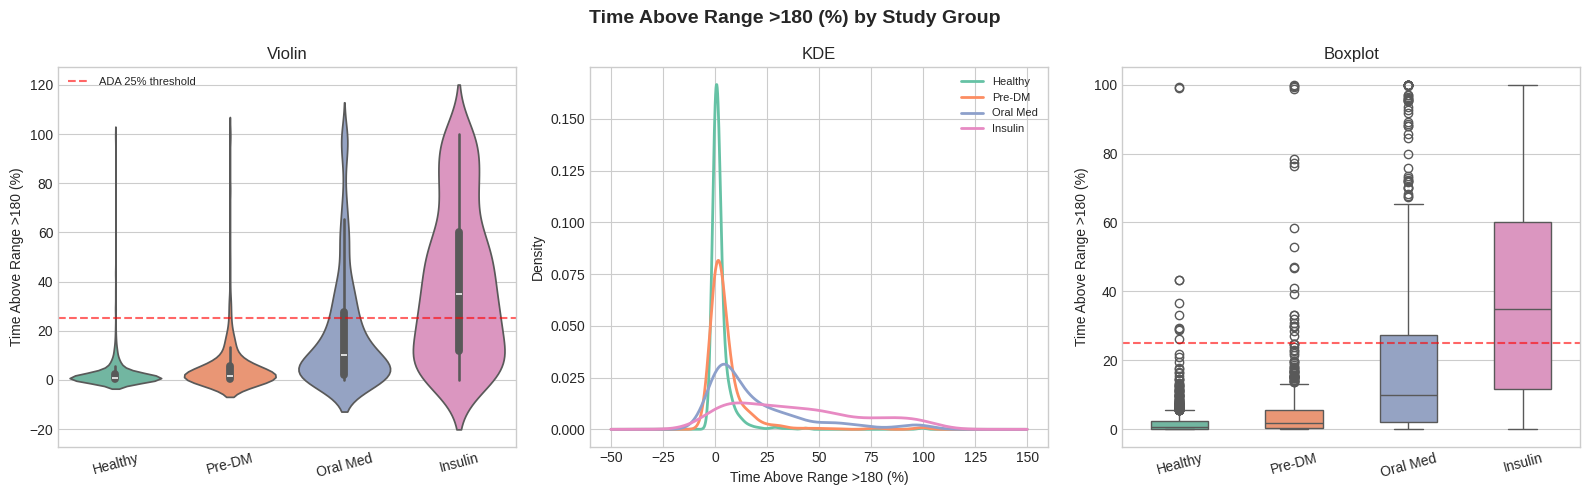

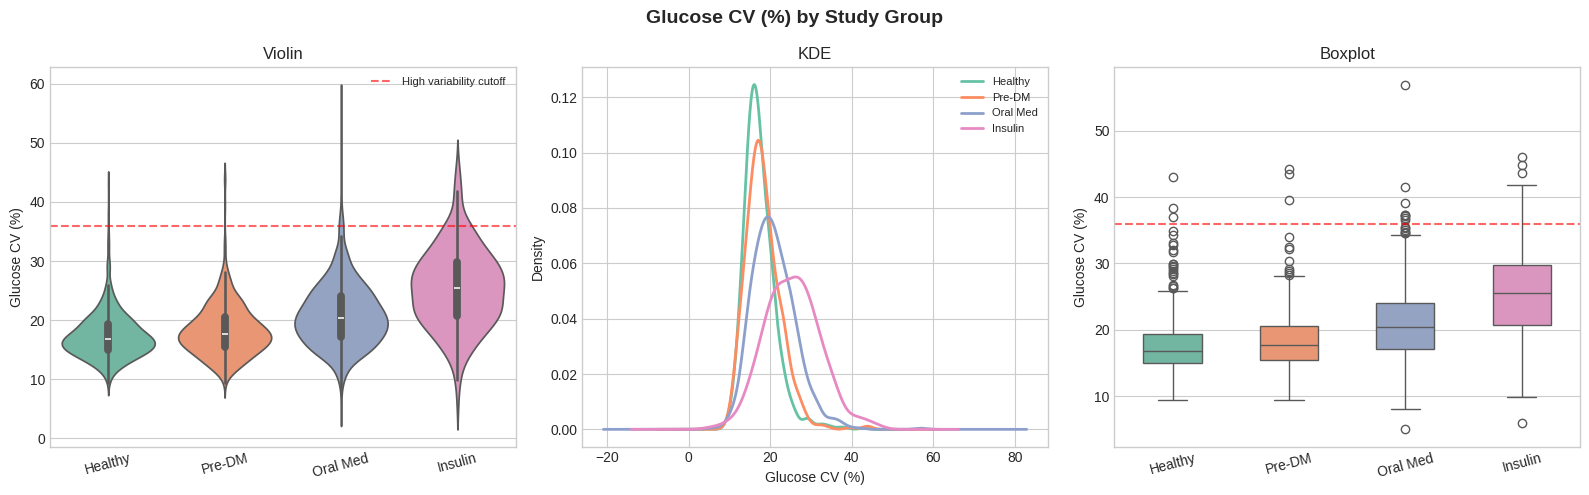

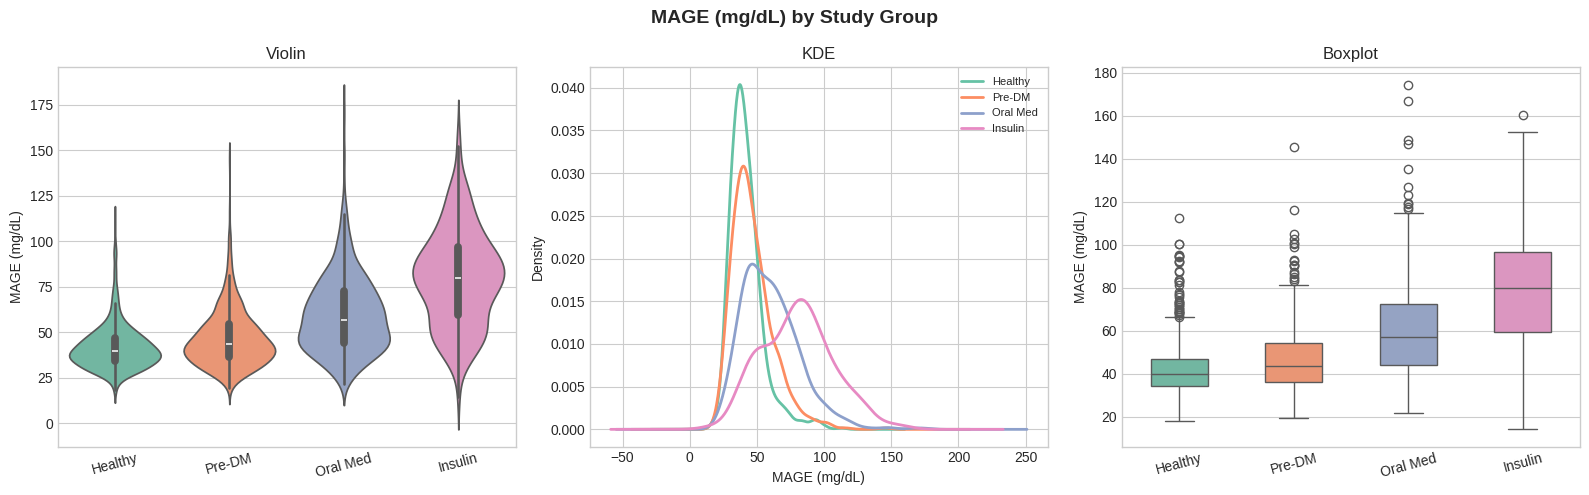

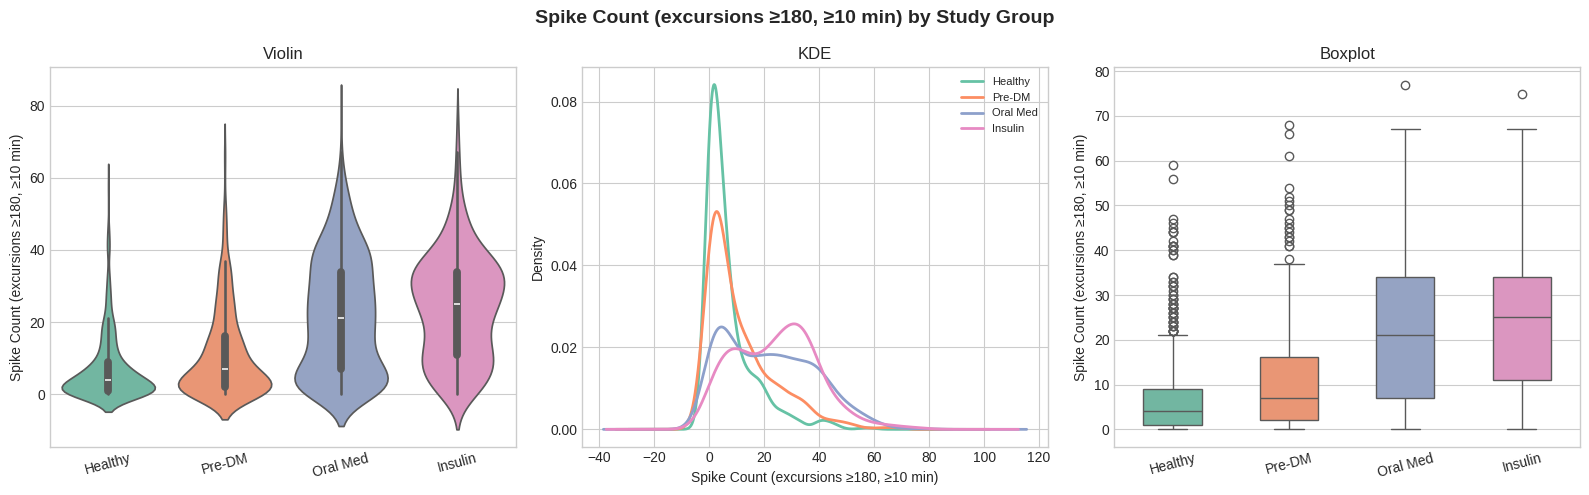

In [14]:
# ── 8. Distribution plots — primary spike metrics ──────────────────
PRIMARY_METRICS = [
    ('tar_180',     'Time Above Range >180 (%)',             25,  'ADA 25% threshold'),
    ('glucose_cv',  'Glucose CV (%)',                        36,  'High variability cutoff'),
    ('mage',        'MAGE (mg/dL)',                          None, None),
    ('spike_count', 'Spike Count (excursions ≥180, ≥10 min)', None, None),
]

for metric, label, ref_line, ref_label in PRIMARY_METRICS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'{label} by Study Group', fontsize=14, fontweight='bold')

    sub = df.dropna(subset=[metric, 'study_group_label'])

    sns.violinplot(data=sub, x='study_group_label', y=metric,
                   order=STUDY_GROUP_ORDER, palette='Set2', inner='box', ax=axes[0])
    axes[0].set_title('Violin'); axes[0].set_xlabel(''); axes[0].set_ylabel(label)
    axes[0].tick_params(axis='x', rotation=15)
    if ref_line:
        axes[0].axhline(ref_line, color='red', linestyle='--', alpha=0.6, label=ref_label)
        axes[0].legend(fontsize=8)

    for grp in STUDY_GROUP_ORDER:
        vals = sub[sub['study_group_label'] == grp][metric]
        if len(vals) > 5:
            vals.plot.kde(ax=axes[1], label=grp, linewidth=2,
                          color=STUDY_GROUP_PAL[grp])
    axes[1].set_title('KDE'); axes[1].set_xlabel(label); axes[1].legend(fontsize=8)

    sns.boxplot(data=sub, x='study_group_label', y=metric,
                order=STUDY_GROUP_ORDER, palette='Set2', width=0.5, ax=axes[2])
    axes[2].set_title('Boxplot'); axes[2].set_xlabel(''); axes[2].set_ylabel(label)
    axes[2].tick_params(axis='x', rotation=15)
    if ref_line:
        axes[2].axhline(ref_line, color='red', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

## 9. Statistical Tests: Spike Metrics × Study Group

In [15]:
# ── 9a. Kruskal-Wallis omnibus + eta-squared ───────────────────────
kw_rows = []
for col in SPIKE_COLS:
    sub    = df.dropna(subset=[col, 'study_group_label'])
    groups = [sub[sub['study_group_label'] == g][col].values for g in STUDY_GROUP_ORDER]
    groups = [g for g in groups if len(g) > 5]
    if len(groups) < 2:
        continue
    H, p = stats.kruskal(*groups)
    k  = len(groups)
    n  = sum(len(g) for g in groups)
    eta2 = (H - k + 1) / (n - k)   # eta-squared
    kw_rows.append({
        'metric': col, 'H': round(H, 3), 'p': p,
        'eta2': round(eta2, 4), 'n': n,
        'sig': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    })

kw_df = pd.DataFrame(kw_rows).sort_values('H', ascending=False)
print('=== Kruskal-Wallis: spike metrics across study groups ===')
print(kw_df.to_string(index=False))

=== Kruskal-Wallis: spike metrics across study groups ===
              metric       H     p  eta2    n sig
          glucose_sd 751.602 0.000 0.334 2243 ***
             tar_180 743.911 0.000 0.331 2243 ***
                 tir 736.030 0.000 0.327 2243 ***
spike_duration_total 728.524 0.000 0.324 2243 ***
          spike_area 723.313 0.000 0.322 2243 ***
 spike_duration_mean 722.635 0.000 0.321 2243 ***
             tar_250 676.040 0.000 0.301 2243 ***
     spike_count_250 645.617 0.000 0.287 2243 ***
                mage 626.097 0.000 0.278 2243 ***
         spike_count 499.444 0.000 0.222 2243 ***
     spike_peak_mean 441.816 0.000 0.221 1992 ***
          glucose_cv 431.219 0.000 0.191 2243 ***
              tbr_70  65.072 0.000 0.028 2243 ***


In [16]:
# ── 9b. Pairwise Mann-Whitney for top 4 metrics (Bonferroni α=0.0083) ──
TOP_KW   = kw_df.nlargest(4, 'H')['metric'].tolist()
BONF_6   = 0.05 / 6

for metric in TOP_KW:
    sub = df.dropna(subset=[metric, 'study_group_label'])
    print(f'\n--- Pairwise Mann-Whitney: {metric} (Bonferroni α={BONF_6:.4f}) ---')
    for g1, g2 in combinations(STUDY_GROUP_ORDER, 2):
        a = sub[sub['study_group_label'] == g1][metric]
        b = sub[sub['study_group_label'] == g2][metric]
        if len(a) < 5 or len(b) < 5:
            continue
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        d    = ((b.mean() - a.mean()) /
                np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2))
        sig  = '***' if p < BONF_6 else ('*' if p < 0.05 else 'ns')
        print(f'  {g1} vs {g2}: U={u:.0f}  p={p:.4f}  d={d:+.3f}  {sig}')


--- Pairwise Mann-Whitney: glucose_sd (Bonferroni α=0.0083) ---
  Healthy vs Pre-DM: U=164814  p=0.0000  d=+0.385  ***
  Healthy vs Oral Med: U=99332  p=0.0000  d=+1.167  ***
  Healthy vs Insulin: U=12194  p=0.0000  d=+2.017  ***
  Pre-DM vs Oral Med: U=103260  p=0.0000  d=+0.825  ***
  Pre-DM vs Insulin: U=14595  p=0.0000  d=+1.740  ***
  Oral Med vs Insulin: U=41017  p=0.0000  d=+1.005  ***

--- Pairwise Mann-Whitney: tar_180 (Bonferroni α=0.0083) ---
  Healthy vs Pre-DM: U=162510  p=0.0000  d=+0.318  ***
  Healthy vs Oral Med: U=94621  p=0.0000  d=+0.951  ***
  Healthy vs Insulin: U=13663  p=0.0000  d=+1.672  ***
  Pre-DM vs Oral Med: U=101022  p=0.0000  d=+0.713  ***
  Pre-DM vs Insulin: U=16505  p=0.0000  d=+1.453  ***
  Oral Med vs Insulin: U=49240  p=0.0000  d=+0.740  ***

--- Pairwise Mann-Whitney: tir (Bonferroni α=0.0083) ---
  Healthy vs Pre-DM: U=246502  p=0.0000  d=-0.299  ***
  Healthy vs Oral Med: U=418040  p=0.0000  d=-0.943  ***
  Healthy vs Insulin: U=177754  p=0.000

In [17]:
# ── 9c. Spearman trend (study_group_code vs each spike metric) ─────
print('=== Spearman trend: study_group_code vs spike metrics ===')
print(f'{"Metric":30s}  {"rho":>8}  {"p":>12}  {"n":>6}')
print('-' * 62)
for col in SPIKE_COLS:
    sub = df[['study_group_code', col]].dropna()
    rho, p = stats.spearmanr(sub['study_group_code'], sub[col])
    print(f'{col:30s}  {rho:+8.4f}  {p:12.4e}  {len(sub):6d}')

=== Spearman trend: study_group_code vs spike metrics ===
Metric                               rho             p       n
--------------------------------------------------------------
spike_count                      +0.4652   7.3923e-121    2243
spike_count_250                  +0.5172   1.0397e-153    2243
spike_duration_mean              +0.5557   5.3563e-182    2243
spike_duration_total             +0.5603   1.2338e-185    2243
spike_area                       +0.5576   1.8760e-183    2243
spike_peak_mean                  +0.4572   1.8613e-103    1992
tir                              -0.5566   1.0347e-182    2243
tar_180                          +0.5650   2.0883e-189    2243
tar_250                          +0.5271   1.3171e-160    2243
tbr_70                           -0.1441    7.0638e-12    2243
glucose_sd                       +0.5643   8.3899e-189    2243
glucose_cv                       +0.4203    1.0715e-96    2243
mage                             +0.5151   3.1030e-152    22

## 10. Spike Metric Correlation Heatmap

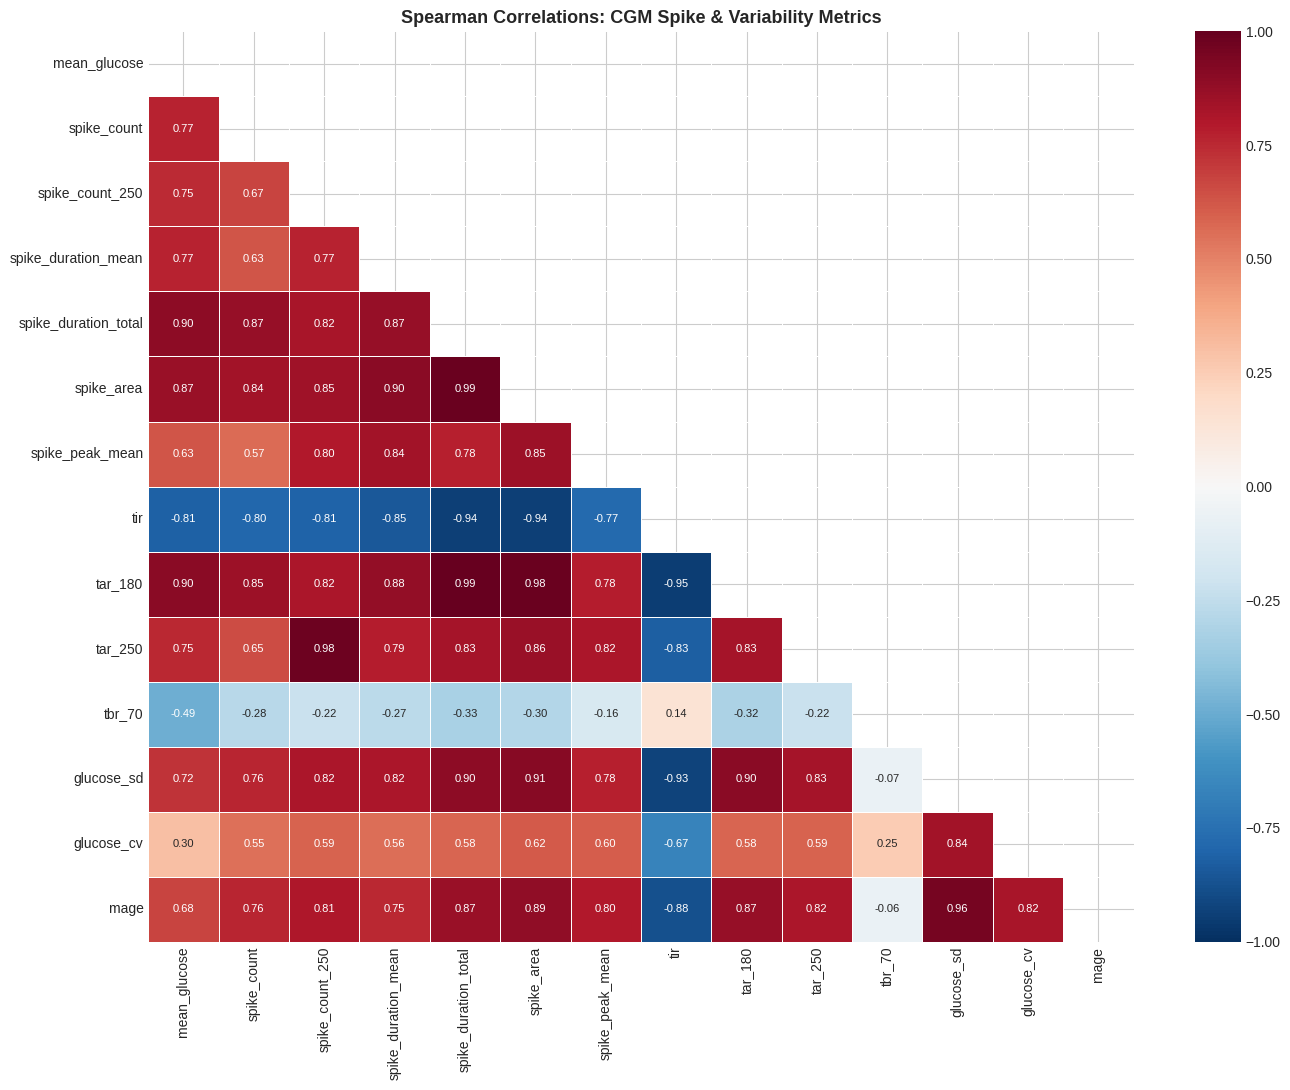

In [18]:
# ── 10. Spearman correlation heatmap ──────────────────────────────
corr_cols = ['mean_glucose'] + SPIKE_COLS if 'mean_glucose' in df.columns else SPIKE_COLS
corr_mat  = df[corr_cols].dropna().corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Spearman Correlations: CGM Spike & Variability Metrics',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Summary Table & Export

In [19]:
# ── 11. Summary by study group & export ───────────────────────────
summary = (
    df.groupby('study_group_label', observed=True)[SPIKE_COLS]
    .agg(['count', 'mean', 'std', 'median'])
    .round(2)
)
print(summary)

# Per-person export (primary output for NB18 & NB20)
export_cols = ['person_id', 'study_group_code', 'study_group_label'] + SPIKE_COLS
df[export_cols].to_csv(out_dir / '17_spike_metrics_per_person.csv', index=False)
print('\nSaved 17_spike_metrics_per_person.csv')

# Summary statistics
summary.to_csv(out_dir / '17_spike_metrics_summary.csv')
print('Saved 17_spike_metrics_summary.csv')

                  spike_count                      spike_count_250         \
                        count   mean    std median           count   mean   
study_group_label                                                           
Healthy                   759  7.050  9.150  4.000             759  0.400   
Pre-DM                    552 11.230 12.300  7.000             552  1.240   
Oral Med                  681 21.760 16.260 21.000             681  5.360   
Insulin                   251 24.250 14.710 25.000             251 11.730   

                                spike_duration_mean          ... glucose_sd  \
                     std median               count    mean  ...        std   
study_group_label                                            ...              
Healthy            1.710  0.000                 759  36.000  ...      5.690   
Pre-DM             4.070  0.000                 552  72.420  ...      7.440   
Oral Med           8.740  1.000                 681 222.560  ... 

## 12. Key Findings

- **Near-complete cohort coverage**: 2,243 of 2,245 participants (99.9%) successfully processed from raw Dexcom G6 JSON. The AI-READI JSON format uses a `body.cgm` structure with `blood_glucose.value` and `effective_time_frame.time_interval.start_date_time` fields — not the flat Dexcom export format.

- **Strong dose-response across all spike metrics**: Every metric shows a significant Kruskal-Wallis omnibus result (p<0.001) across the four disease severity groups. TAR >180 Spearman trend: rho=+0.565, p=2.09e-189. MAGE trend: rho=+0.515, p=3.10e-152. TIR shows the expected strong negative trend.

- **Very large effect sizes Healthy → Insulin**: glucose_sd Cohen's d=+2.017, tar_180 d=+1.672. These are exceptionally large effects reflecting the fundamental difference in glycemic physiology between medication-naive healthy participants and insulin-dependent patients.

- **Insulin group has highest variability, not just highest mean**: glucose_cv and MAGE peak in the Insulin group, reflecting the wide swings produced by exogenous insulin dosing on top of impaired endogenous regulation — a pattern that mean glucose alone cannot capture.

- **Spike metrics are highly intercorrelated**: tar_180, spike_count, spike_area, and spike_duration are all collinear (they all measure hyperglycemia burden from different angles). glucose_cv and MAGE form a distinct cluster capturing intra-person variability independent of the absolute hyperglycemia level.

- **Modeling implication**: For downstream models, tar_180 and glucose_cv together capture the two orthogonal dimensions of CGM variability; adding additional spike metrics beyond these two provides limited incremental information.